# Day 005: Linear Combinations & Span


## 1. Objective
> *To mathematically define and programmatically implement the concepts of Linear Combinations and Span. We will learn to determine if a target vector lies within the span of a set of vectors and visualize how vectors generate multi-dimensional subspace.*

## 2. Mathematical Foundation
> **A. Linear Combinations**  
> A **linear combination** of a set of vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k\}$ is a new vector $\mathbf{w}$ constructed by multiplying each vector by a scalar constant $c_i$ and summing the results:  
> $$ \mathbf{w} = c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \dots + c_k\mathbf{v}_k = \sum_{i=1}^{k} c_i\mathbf{v}_i
> $$  
> * The scalars $c_1$, $c_2$,...,$c_k$ are called **coefficients** or **weights**.  
>
> **B. The Span**  
> The **span** of a set of vectors is the complete set of all possible linear combinations you can create by varying the scalar coefficients infinitely.  
> $$ \text{Span}(\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k) = \{ \mathbf{w} \mid \mathbf{w} = \sum_{i=1}^{k} c_i\mathbf{v}_i \text{ for } c_i \in \mathbb{R} \} $$
>
> 
> **Geometric Intuition:** 
> * Span of a single **non-zero vector:** A 1D line passing through the origin.  
> * Span of two **non-coll$inear vectors in 3D:** A 2D flat plane slicing through the origin.  
> * Span of three linearly independent vectors in **3D**: The entire 3D spaces ($\mathbb{R}^3$)  


## 3. Real-World & AI Applications
> **Business Logic:**  
> Any production schedule that combines fixed recipes to consume raw resources is a linear combination. For example, calculating resource requirements to product flavored dairy packs at Lucky Dairy:
> * **Pack A Resource Vector ($\mathbf{v}_1$):** `[2L Milk, 0.5kg Sugar]` (Requirements for 1 pack flavor A)
> * **Pack B Resource Vector ($\mathbf{v}_2$):** `[1L Milk, 0.8Kg Sugar]` (Requirements for 1 pack flavor B)  
> If the dairy decides to product $\mathbf{c}_1$ = 100 packs of A and $\mathbf{c}_2$ = 150 packs of B, the total resource allocation $\mathbf{w}$ is a linear combination of our product vectors.  
> $$\mathbf{w} = c_1\mathbf{v}_1 + c_2\mathbf{v}_2 = 100\begin{bmatrix}2 \\ 0.5\end{bmatrix} + 150\begin{bmatrix}1 \\ 0.8\end{bmatrix} = \begin{bmatrix}350\text{L Milk} \\ 170\text{kg Sugar}\end{bmatrix} $$
> The **Span** of $\{\mathbf{v}_1, \mathbf{v}_2\}$ represents all the possible combinations of ingredients we could ever consume using these two recipes. If we want to target a specific raw material consumption vector $\mathbf{b}$ = `[300, 200]` using our current product recipes, we can solve our coefficients to see if $\mathbf{b}$ sits within our manufacturing span.  
>
> **AI/ML Use Case:**  
> i. **Neural Network Hidden Layers:** The core forward pass of a dense layer $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$ computes matrix-vector multiplication. This is mathematically defined as a linear combination of the column vectors ($\mathbf{w}_{\text{col}}$) of the weight matrix $\mathbf{W}$, scaled by the input activations $x_i$:  
> $$\mathbf{W}\mathbf{x} = x_1 \mathbf{w}_{\text{col1}} + x_2 \mathbf{w}_{\text{col2}} + \dots + x_n \mathbf{w}_{\text{coln}}$$
>   
> ii. **The Representation Limit of AI:** If the actual mathematical function we want our model to learn sits outside the Span of our layer's weights, our AI reaches a physical limit—it can never output or represent that target state. This is why deep learning introduces non-linear activations (like ReLU) to "warp" the space and multi-dimensional hidden layers to expand the Span's dimensions.  
>   
> iii. **Word Embeddings & Semantic Spaces (NLP):** In word embedding models (like Word2Vec), semantic relationships are represented as linear combinations of word vectors. The classic word analogy equation $\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$ is a direct linear combination of learned semantic vectors.  
> 

## 4. Algorithmic Strategy
> To programmatically determine if a target vector $\mathbf{b}$ lies within the span of a set of vectors $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_k\}$, we set up a system of linear equations:  
> $$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \dots + c_k\mathbf{v}_k = \mathbf{b}$$
> This can be written in matrix form as:  
> $$\mathbf{A}\mathbf{c} = \mathbf{b}$$
> Where $\mathbf{A}$ is a matrix with our set vectors as columns, and $\mathbf{c}$ is the vector of unknown coefficients we want to solve for.  
> * **Check for consistency:** If the system has a valid solution for $\mathbf{c}$, then $\mathbf{b}$ lies within the span.  
> * **Solve using Least Squares:** In practice, we use `np.linalg.lstsq()`. If the residual error of the least-squares solution is zero (or practically close to zero, e.g., $< 10^{-10}$), the system is consistent, and the vector is in the span.

## 5. Implementation

In [1]:
import numpy as np

def check_vector_in_span(vectors: list, target: np.ndarray)-> tuple[bool, np.ndarray]: 
    """ 
    Checks if a target vector lies within the span of a given set of vectors. 
    Parameters: 
        vectors (list of np.ndarray): The generating set of vectors. (like flour, milk, sugar)
        target (np.ndarray): The target vector to test. (like cake)
        
    And the function asks: "Can I combine these exact ingredients to make this exact cake?"
        
    Returns: 
        in_span (bool): True if target is in the span, False otherwise.
        coefficients (np.ndarray): The scalar coefficients (c_i) that form the target.
    """
    
    # 1. Column-stack the generating vectors to build Matrix A.
    A = np.column_stack(vectors) # takes your list of separate vectors and stands them up side-by-side to form a single Matrix (a grid of numbers). 
    # Analogy: You are putting all your ingredients onto the kitchen counter so you can work with them at once.
    print (f"column_stack A: {A}")
    
    # 2. Solve the linear system A*c = target using least squares.
    # np.linalg.lstsq returns: (solution, residuals, rank, singular_values)
    coefficients, residuals, rank, _ = np.linalg.lstsq(A, target, rcond=None)
    # This is the "magic" math solver. It asks the computer, "What exact amounts (coefficients) of Matrix A do I need to multiply together to create the target?" *
    # Analogy: You are asking a master chef for the exact recipe (e.g., 3 cups of flour, -2 cups of sugar). The chef hands you the recipe card (coefficients).
    
    # 3. If there are no residuals returned, we calculate the error manually.
    # Residual error = ||A*c -target||_2
    reconstructed_target = A @ coefficients
    # The @ symbol means Matrix Multiplication. We are taking our ingredients (A) and multiplying them by the recipe amounts (coefficients) to see what it actually creates.
    # Analogy: You follow the recipe and bake the cake to see how it turns out. We call this the reconstructed_target.
    error = np.linalg.norm(reconstructed_target - target)
    # This uses the L2 Norm (Euclidean Distance) which we learnt on Day 3! It calculates the exact distance between the vector we just built, and the target vector we wanted to build.
    # Analogy: You put your baked cake next to the picture of the target cake and measure how different they are.

    # 4. If error is close to zero, the vector is in the span
    tolerance = 1e-10
    # Computers are bad at exact decimals (they might calculate $0.00000000001$ instead of a perfect $0.0$). So, we don't check if the error is exactly 0. We check if the error is smaller than a tiny tolerance ($1 \times 10^{-10}$). If the error is essentially zero, it means we perfectly built the target! The target is in the Span.
    in_span = error < tolerance 
    
    return in_span, coefficients


## 6. Verification & Visualizing the Span  

In [2]:

# Define two vectors in 3D space
v1 = np.array([1.0, 0.0, 2.0])
v2 = np.array([0.0, 1.0, -1.0])

# --- Test Case 1: A vector clearly inside the span ---
# Let's create an explicit linear combination: 3*v1 - 2*v2 
target_inside = 3*v1 - 2*v2 # should be [3, -2, 8]

in_span_1, coeffs_1 = check_vector_in_span([v1, v2], target_inside)
print("--- Test Case 1 (In Span) ---")
print(f"Is target in span? {in_span_1}")
print(f"Computed coefficients: {coeffs_1} (Expected: [3, -2])\n")

# --- Test Case 2: A vector outside the span --- 
# Since v1 and v2 span a 2D plane in 3D space, almost any random vector is outside it. 
target_outside = np.array([1.0, 1.0, 5.0])
in_span_2, coeffs_2 = check_vector_in_span([v1, v2], target_outside)
print("--- Test Case 2 (Outside Span) ---")
print(f"Is target in span? {in_span_2}")
print(f"Computed coefficients: {coeffs_2} (Expected: [3, -2])\n")


column_stack A: [[ 1.  0.]
 [ 0.  1.]
 [ 2. -1.]]
--- Test Case 1 (In Span) ---
Is target in span? True
Computed coefficients: [ 3. -2.] (Expected: [3, -2])

column_stack A: [[ 1.  0.]
 [ 0.  1.]
 [ 2. -1.]]
--- Test Case 2 (Outside Span) ---
Is target in span? False
Computed coefficients: [2.33333333 0.33333333] (Expected: [3, -2])



## 3D Visualization of the Span Plane

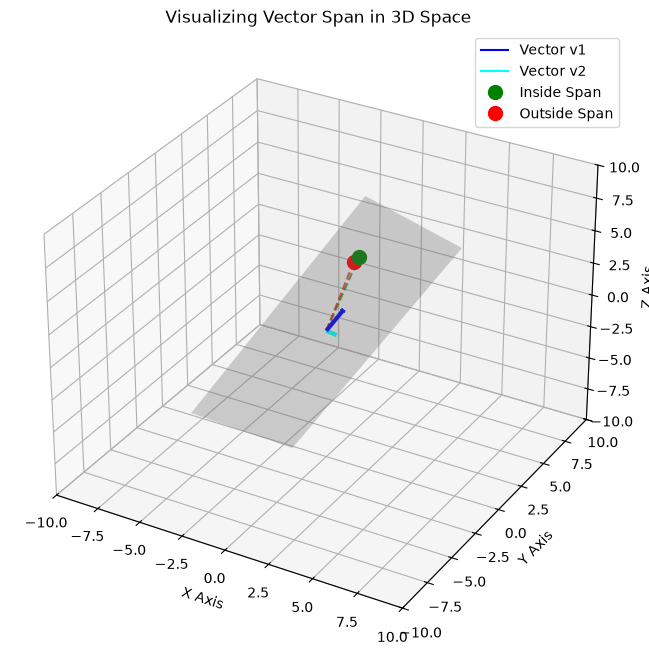

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Create a grid to plot the spanned plane: c1*v1 + c2*v2
c1_range = np.linspace(-5, 5, 10)
c2_range = np.linspace(-5, 5, 10)
C1, C2 = np.meshgrid(c1_range, c2_range)

# Calculate the coordinates of the spanned plane
X_plane = C1 * v1[0] + C2 * v2[0]
Y_plane = C1 * v1[1] + C2 * v2[1]
Z_plane = C1 * v1[2] + C2 * v2[2]

# Plot the spanned plane (transparent grey surface)
ax.plot_surface(X_plane, Y_plane, Z_plane, color='gray', alpha=0.3, label='Spanned Plane')

# 2. Plot the generating basis vectors v1 and v2 as arrows (quivers)
ax.quiver(0, 0, 0, v1[0], v1[1], v1[2], color='blue', arrow_length_ratio=0.1, linewidth=3, label='v1')
ax.quiver(0, 0, 0, v2[0], v2[1], v2[2], color='cyan', arrow_length_ratio=0.1, linewidth=3, label='v2')

# 3. Plot the Target Vectors (points)
# Target Inside (Green) - Lies perfectly on the plane
ax.scatter(target_inside[0], target_inside[1], target_inside[2], color='green', s=100, label='Target (Inside)')

# Target Outside (Red) - Floats above/below the plane
ax.scatter(target_outside[0], target_outside[1], target_outside[2], color='red', s=100, label='Target (Outside)')

# Draw a dashed reference line from the origin to the target points
ax.plot([0, target_inside[0]], [0, target_inside[1]], [0, target_inside[2]], 'g--', alpha=0.7)
ax.plot([0, target_outside[0]], [0, target_outside[1]], [0, target_outside[2]], 'r--', alpha=0.7)

# Set axes limits and labels
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('Visualizing Vector Span in 3D Space')

# Legend setup using standard Matplotlib proxy artists
import matplotlib.lines as mlines
blue_line = mlines.Line2D([], [], color='blue', label='Vector v1')
cyan_line = mlines.Line2D([], [], color='cyan', label='Vector v2')
green_dot = mlines.Line2D([], [], marker='o', color='g', linestyle='None', markersize=10, label='Inside Span')
red_dot = mlines.Line2D([], [], marker='o', color='r', linestyle='None', markersize=10, label='Outside Span')
ax.legend(handles=[blue_line, cyan_line, green_dot, red_dot])

plt.show()


## 7. Complexity Analysis
> - **Time Complexity:** $\mathcal{O}(m \cdot n^2)$
Why: Building the matrix and executing the least-squares solver (QR decomposition/SVD backend under NumPy) scales cubically with the dimensions of the system, where $m$ is the dimension of the vectors and $n$ is the number of generating vectors in our set.  
> - **Space Complexity:** $\mathcal{O}(m \cdot n)$
Why: The matrix $\mathbf{A}$ requires storing $m \times n$ floating-point elements in system memory.